## Derivación Uniforme
Para la distribución uniforme:

$$ p(x) = \frac{1}{b-a} ; a \leq x \leq b$$

$$ E[x] = \int xp(x)dx = \int_{a}^{b} \frac{x}{b-a}dx = \Big| \frac{x^2}{2(b-a)}\Big|_{a}^{b} = \frac{b^2-a^2}{2(b-a)} = \frac{b+a}{2} = \frac{a+b}{2}$$

$$ E[x^2] = \int x^2p(x)dx = \int_{a}^{b} \frac{x^2}{b-a}dx = \Big| \frac{x^3}{3(b-a)}\Big|_{a}^{b} = \frac{b^3-a^3}{3(b-a)} = \frac{b^2 + ab + a^2}{3}$$

$$ Var(x) = E[x^2] - E[x]^2 = \frac{a^2+ab+b^2}{3} - (\frac{a+b}{2})^2 = \frac{4(a^2+ab+b^2) - 3(a^2+2ab+b^2)}{12} = \frac{a^2 - 2ab + b^2}{12} = \frac{(b-a)^2}{12}$$

## Derivación Exponencial

Para la distribución exponencial:
$$ p(x) = \lambda e^{-\lambda x} ; 0 \leq x $$

$$ E[x] = \int xp(x)dx = \int_{0}^{\infty} x\lambda e^{-\lambda x} dx$$

$$ u = x; du=dx; dv = \lambda e^{-\lambda x} dx; v = -e^{-\lambda x} $$

$$ E[x] = -xe^{-\lambda x} - \int -e^{-\lambda x} dx = -x e^{-\lambda x} - \frac{1}{\lambda}e^{-\lambda x} = \Big|-e^{-\lambda x }(x + \frac{1}{\lambda})\Big|_{0}^{\infty} = 0 + \frac{1}{\lambda} = \frac{1}{\lambda}$$

$$ E[x^2] = \int x^2p(x^2)dx = \int x^2 \lambda e^{-\lambda x^2}dx $$

$$ u = x^2; du = 2xdx; dv = \lambda e^{-\lambda x}dx; v = -e^{-\lambda x} $$

$$ -x^2 e^{-\lambda x} - \int -2xe^{-\lambda x} dx = -x^2e^{-\lambda x} + 2\int xe^{-\lambda x} dx$$

$$ u= x ; du=dx; dv= e^{-\lambda x}dx; v = -\frac{1}{\lambda}e^{-\lambda x} $$

$$ -x^2e^{-\lambda x} + 2(-\frac{1}{\lambda}xe^{-\lambda x} - \int -\frac{1}{\lambda} e^{-\lambda x} dx) = -x^2 e^{-\lambda x } - \frac{2}{\lambda}xe^{-\lambda x} + \frac{2}{\lambda}\int e^{-\lambda x} dx = -x^2e^{-\lambda x} - \frac{2}{\lambda}xe^{-\lambda x} - \frac{2}{\lambda^2} e^{-\lambda x} = \Big|-e^{-\lambda x}(x^2 + \frac{2}{\lambda}x + \frac{2}{\lambda^2})\Big|_{0}^{\infty} = 0 + \frac{2}{\lambda^2} = \frac{2}{\lambda^2}$$

$$ Var[x] = E[x^2] - E[x]^2 = \frac{2}{\lambda^2}-(\frac{1}{\lambda})^2 = \frac{2-1}{\lambda^2} = \frac{1}{\lambda^2}$$

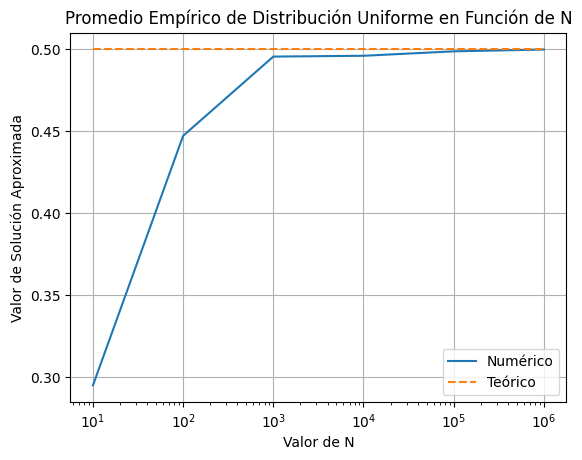

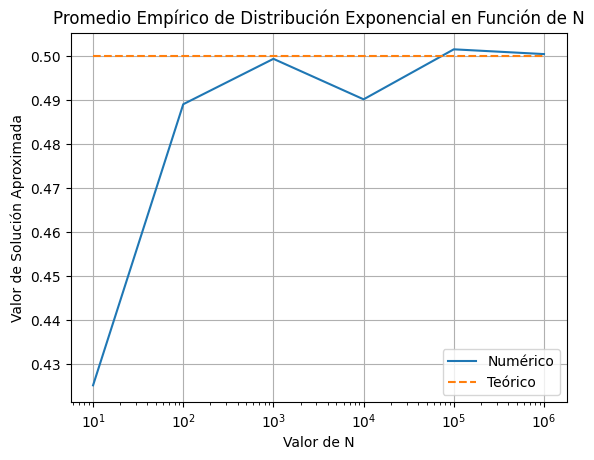

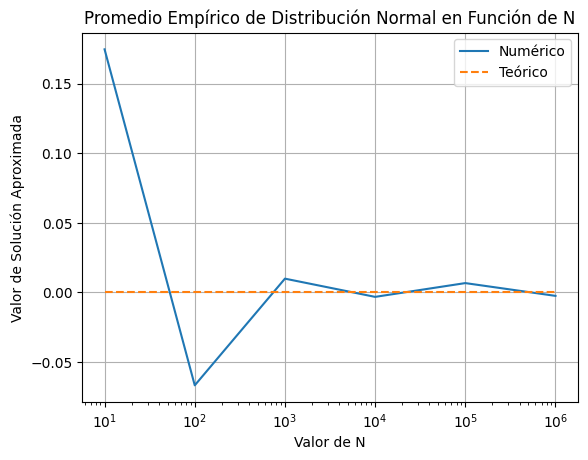

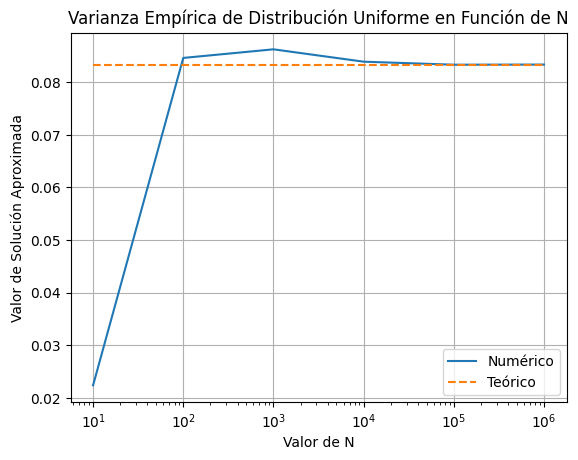

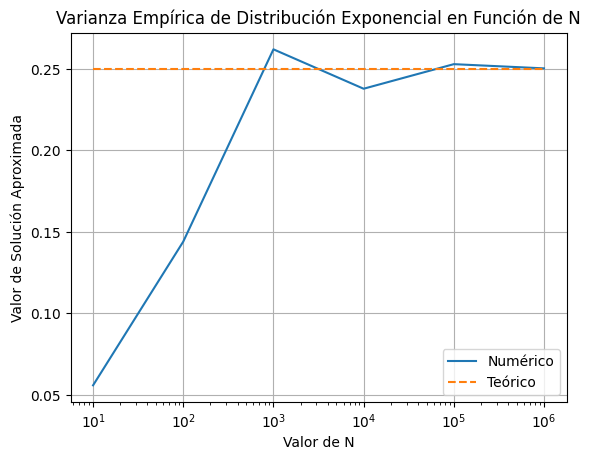

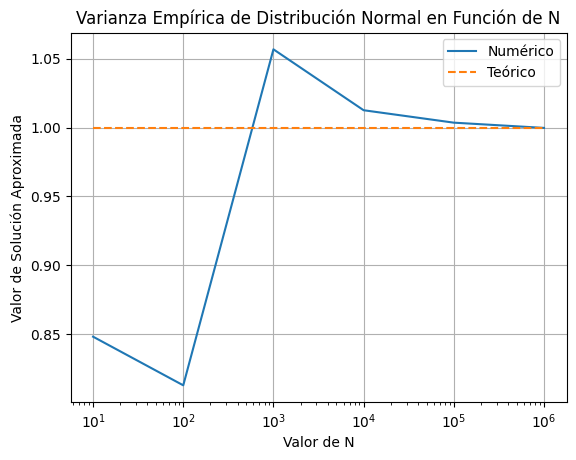

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros

a = 0
b = 1
l = 2
m = 0
s = 1

# Valores de N

N = [10, 100, 1000, 10000, 100000, 1000000]

# Listas de Promedios

uniforme = []
exponencial = []
normal = []

# Listas de Varianzas

varianza_u = []
varianza_e = []
varianza_n = []

# Promedios Teóricos

promedio_u_teorico = [(a + b)/2] * len(N)
promedio_e_teorico = [1/l] * len(N)
promedio_n_teorico = [m] * len(N)

# Varianzas Teóricas

varianza_u_teorica = [((b - a)**2)/12] * len(N)
varianza_e_teorica = [1/(l**2)] * len(N)
varianza_n_teorica = [s**2] * len(N)

# Cálculos Numéricos

for n in N:
  x_uniforme = np.random.uniform(a, b, size=n)
  y_uniforme = (1/n)*sum(x_uniforme)
  uniforme.append(y_uniforme)

  diferencia_u = [(x - y_uniforme)**2 for x in x_uniforme]
  s_uniforme = (1/n)*sum(diferencia_u)
  varianza_u.append(s_uniforme)

  x_exponencial = np.random.exponential(scale=(1/l), size=n)
  y_exponencial = (1/n)*sum(x_exponencial)
  exponencial.append(y_exponencial)

  diferencia_e = [(x - y_exponencial)**2 for x in x_exponencial]
  s_exponencial = (1/n)*sum(diferencia_e)
  varianza_e.append(s_exponencial)

  x_normal = np.random.normal(m, s, size=n)
  y_normal = (1/n)*sum(x_normal)
  normal.append(y_normal)

  diferencia_n = [(x - y_normal)**2 for x in x_normal]
  s_normal = (1/n)*sum(diferencia_n)
  varianza_n.append(s_normal)

# Figura Promedio Uniforme

plt.figure()

plt.plot(N, uniforme, label="Numérico")
plt.plot(N, promedio_u_teorico, label="Teórico", linestyle="--")

plt.title("Promedio Empírico de Distribución Uniforme en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()

# Figura Promedio Exponencial

plt.figure()

plt.plot(N, exponencial, label="Numérico")
plt.plot(N, promedio_e_teorico, label="Teórico", linestyle="--")

plt.title("Promedio Empírico de Distribución Exponencial en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()

# Figura Promedio Normal

plt.figure()

plt.plot(N, normal, label="Numérico")
plt.plot(N, promedio_n_teorico, label="Teórico", linestyle="--")

plt.title("Promedio Empírico de Distribución Normal en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()

# Figura Varianza Uniforme

plt.figure()

plt.plot(N, varianza_u, label="Numérico")
plt.plot(N, varianza_u_teorica, label="Teórico", linestyle="--")

plt.title("Varianza Empírica de Distribución Uniforme en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()

# Figura Varianza Exponencial

plt.figure()

plt.plot(N, varianza_e, label="Numérico")
plt.plot(N, varianza_e_teorica, label="Teórico", linestyle="--")

plt.title("Varianza Empírica de Distribución Exponencial en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()

# Figura Varianza Normal

plt.figure()

plt.plot(N, varianza_n, label="Numérico")
plt.plot(N, varianza_n_teorica, label="Teórico", linestyle="--")

plt.title("Varianza Empírica de Distribución Normal en Función de N")
plt.xlabel("Valor de N")
plt.ylabel("Valor de Solución Aproximada")
plt.xscale("log")

plt.grid(True)
plt.legend()
plt.show()